In [2]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from scipy.stats import skew
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV


In [3]:
df = pd.read_csv('../data/raw/dataset-6ab989b678d90892980305.csv')

In [4]:
df_clean = df.copy()

In [5]:
# Drop the one null row from CREDIT_LIMIT

df_clean.dropna(subset=['CREDIT_LIMIT'], inplace=True)

In [6]:
df_clean.to_csv('../data/processed/card_profiler_clean.csv')

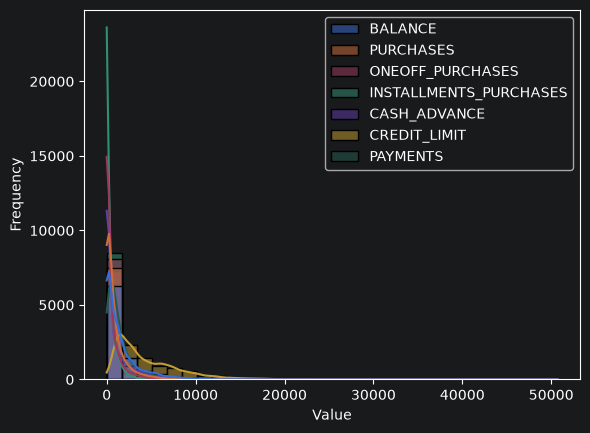

In [7]:
sns.histplot(df_clean, kde=True, color="crimson", bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [8]:
numeric_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
                 "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

df_prepare_clustering = df_clean[numeric_cols].copy()

for i in numeric_cols:
    df_prepare_clustering[f"{i}_log"] = np.log1p(df[i])
    df_prepare_clustering.drop(columns=i, inplace=True)



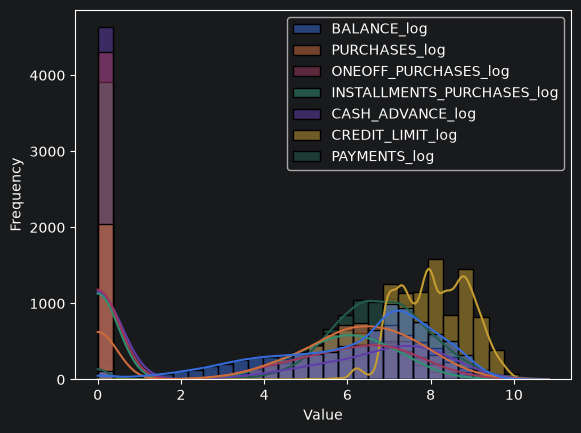

In [9]:

sns.histplot(df_prepare_clustering, kde=True, color="crimson", bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_prepare_clustering)

In [11]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

variance_per_pc = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_per_pc)

min_components = np.argmax(cumulative_variance > 0.80) + 1

print(min_components)



4


In [12]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)
variance_per_pc = pca.explained_variance_ratio_

for i, ratio in enumerate(variance_per_pc):
    print(f"PC{i+1} {ratio:.2%}")
print(f"{sum(variance_per_pc):.2%}")
df_prepare_clustering = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_prepare_clustering.head()

PC1 35.36%
PC2 29.26%
PC3 11.40%
PC4 10.01%
86.02%


,PC1,PC2,PC3,PC4
0,-0.457236,-2.343430,-0.574133,-0.425904
1,-2.100598,2.188513,-0.561805,0.616495
2,0.829442,0.714435,1.569019,0.517618
3,-0.334924,-0.589284,3.087780,1.127924
4,-0.940884,-0.636421,0.604596,-0.870138


In [ ]:

# Define the parameter grid
param_grid = {
    'n_clusters': range(2, 5),
    'init': ['k-means++', 'random'],
    'n_init': [5, 10, 15],
    'max_iter': [100, 200, 300, 400, 500],
    'tol': [0.0001, 0.001, 0.01],
    'algorithm': ['auto', 'full', 'elkan'],
    'random_state': [0, 42, 100]
}

# Create the KMeans object
kmeans = KMeans(random_state=42)

# Perform grid search
grid_search = GridSearchCV(kmeans, param_grid=param_grid, cv=5, n_jobs=-1)

X_kmeans= kmeans.fit_transform(df_prepare_clustering)

# Fit the grid search to the data
grid_search.fit(X_kmeans)

# Print the best hyperparameters
print("Best hyperparameters: ", grid_search.best_params_)
print('Optimal number of clusters based on parameter grid: ' + str(grid_search.best_params_['n_clusters']))

